# Gradient transfer fusion (GTF)

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

RENDERS = Path("/mnt/c/Users/olive/Desktop/Blender/war_town/renders")
DATASET = Path("../..")  # repo root; VTUAV-style sequences: <seq>/rgb/*.jpg + <seq>/ir/*.jpg, frame-aligned

# Every available (visible, thermal) input pair. A source is either an .mp4 file or a directory of images.
SOURCES = {
    "war_town": (RENDERS / "visible.mp4", RENDERS / "thermal.mp4"),
    **{r.parent.name: (r, r.parent / "ir") for r in sorted([*DATASET.glob("*/rgb"), *DATASET.glob("*/*/rgb")]) if r.is_dir()},
}
SOURCE = "car_008"
VISIBLE, THERMAL = SOURCES[SOURCE]
OUTPUT = Path(f"../out/gtf_{SOURCE}.mp4")

SEQ_FPS = 30.0     # frame rate assumed for image-sequence sources
MAX_FRAMES = None  # set to a small number for a quick preview
print("available:", list(SOURCES)); print("using:", SOURCE)

available: ['war_town', 'car_008']
using: car_008


## Parameters

In [2]:
LAMBDA = 4.0
MIX = 0.0

## Video I/O

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


class FrameSource:
    """Sequential frame reader over either a video file or a directory of images (sorted by name)."""

    def __init__(self, path):
        self.path = Path(path)
        self.is_dir = self.path.is_dir()
        if self.is_dir:
            self.files = sorted(p for p in self.path.iterdir() if p.suffix.lower() in IMAGE_EXTS)
            if not self.files:
                raise FileNotFoundError(f"no images in {self.path}")
        elif not self.path.is_file():
            raise FileNotFoundError(f"could not find video: {self.path}")

    def info(self):
        if self.is_dir:
            h, w = cv2.imread(str(self.files[0])).shape[:2]
            return dict(width=w, height=h, fps=SEQ_FPS, frame_count=len(self.files))
        cap = cv2.VideoCapture(str(self.path))
        if not cap.isOpened():
            raise FileNotFoundError(f"could not open video: {self.path}")
        try:
            return dict(
                width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
                fps=float(cap.get(cv2.CAP_PROP_FPS)),
                frame_count=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
            )
        finally:
            cap.release()

    def __iter__(self):
        if self.is_dir:
            for f in self.files:
                yield cv2.imread(str(f))
            return
        cap = cv2.VideoCapture(str(self.path))
        try:
            while True:
                ok, frame = cap.read()
                if not ok:
                    return
                yield frame
        finally:
            cap.release()

    def read(self, index):
        if self.is_dir:
            return cv2.imread(str(self.files[index]))
        cap = cv2.VideoCapture(str(self.path))
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)
        ok, frame = cap.read()
        cap.release()
        if not ok:
            raise IndexError(f"no frame {index} in {self.path}")
        return frame


def probe(path):
    return FrameSource(path).info()


def iter_frame_pairs(visible, thermal):
    """Yield (visible_bgr, thermal_bgr) pairs until either stream ends."""
    for frame_v, frame_t in zip(FrameSource(visible), FrameSource(thermal)):
        if frame_v.shape[:2] != frame_t.shape[:2]:
            raise ValueError(f"frame size mismatch: {frame_v.shape[:2]} vs {frame_t.shape[:2]}")
        yield frame_v, frame_t


def read_frame(path, index):
    return FrameSource(path).read(index)


def to_gray01(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0


def fuse(visible_bgr, thermal_bgr):
    """Fuse only the luminance (Y) channel; keep the visible image's colour (CrCb)."""
    ycc = cv2.cvtColor(visible_bgr, cv2.COLOR_BGR2YCrCb).astype(np.float32) / 255.0
    ycc[..., 0] = fuse_gray(ycc[..., 0], to_gray01(thermal_bgr))
    return cv2.cvtColor((np.clip(ycc, 0, 1) * 255).astype(np.uint8), cv2.COLOR_YCrCb2BGR)


info_v, info_t = probe(VISIBLE), probe(THERMAL)
assert (info_v["width"], info_v["height"]) == (info_t["width"], info_t["height"]), "resolution mismatch"
info_v, info_t

({'width': 1920, 'height': 1080, 'fps': 30.0, 'frame_count': 5933},
 {'width': 1920, 'height': 1080, 'fps': 30.0, 'frame_count': 5933})

## Method

In [4]:
def _laplacian_eigs(h, w):
    # eigenvalues of the discrete negative Laplacian under periodic boundaries
    fy = np.fft.fftfreq(h)[:, None]
    fx = np.fft.fftfreq(w)[None, :]
    return 4.0 - 2.0 * np.cos(2 * np.pi * fy) - 2.0 * np.cos(2 * np.pi * fx)


def gradient_transfer(t, v, lam):
    """argmin_x ||x - t||^2 + lam * ||grad x - grad v||^2, solved in the Fourier domain."""
    L = _laplacian_eigs(*t.shape)
    T, V = np.fft.fft2(t), np.fft.fft2(v)
    X = (T + lam * L * V) / (1.0 + lam * L)
    return np.real(np.fft.ifft2(X)).astype(np.float32)


def fuse_gray(yv, t):
    x = gradient_transfer(t, yv, LAMBDA)
    if MIX > 0:
        x = (1 - MIX) * x + MIX * yv
    return np.clip(x, 0, 1)

## Preview a single frame

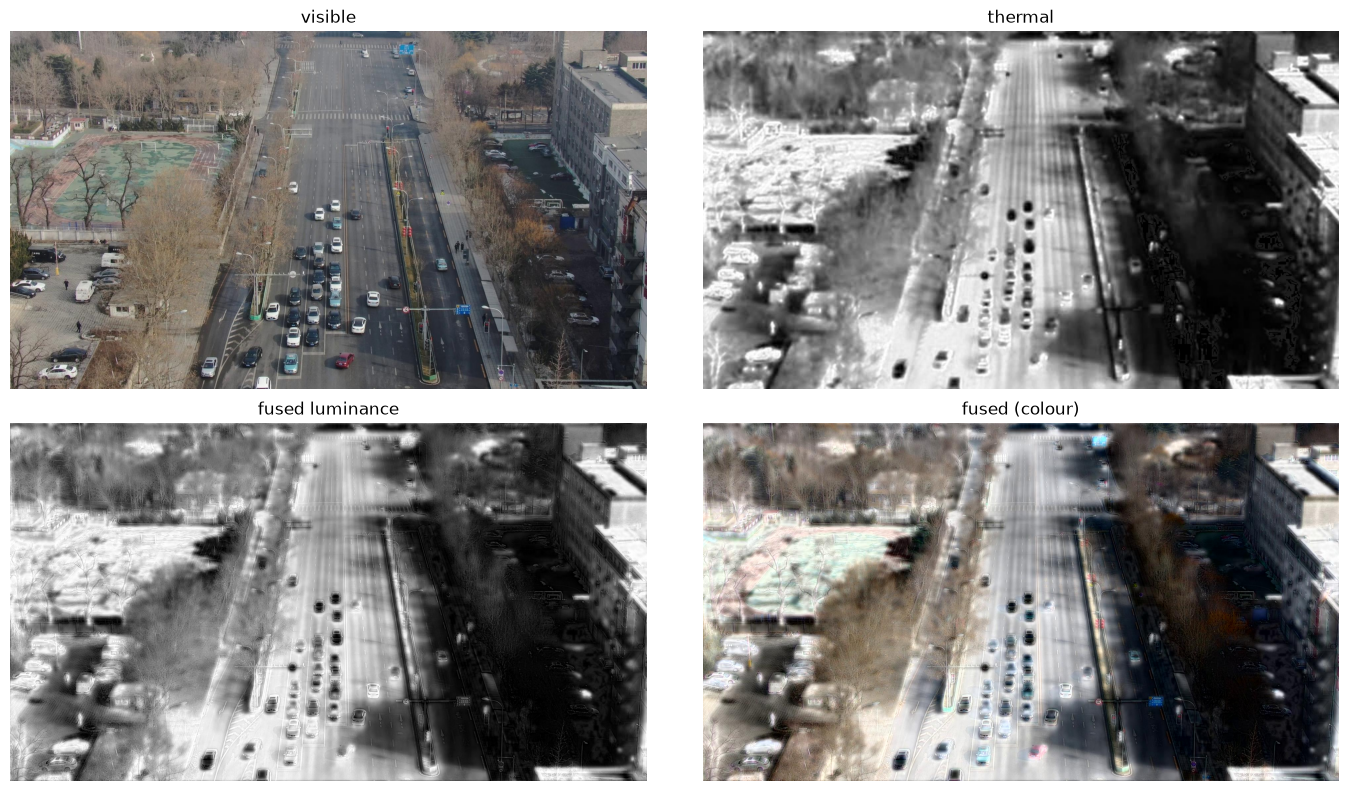

In [5]:
FRAME = 30
v, t = read_frame(VISIBLE, FRAME), read_frame(THERMAL, FRAME)
yv, tg = to_gray01(cv2.cvtColor(v, cv2.COLOR_BGR2YCrCb)[..., 0:1].repeat(3, 2)), to_gray01(t)
y_fused = fuse_gray(yv, tg)
o = fuse(v, t)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
panels = [("visible", v), ("thermal", t), ("fused luminance", y_fused), ("fused (colour)", o)]
for ax, (title, img) in zip(axes.flat, panels):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title); ax.axis("off")
plt.tight_layout()

## Run over the whole video

In [6]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
writer = cv2.VideoWriter(str(OUTPUT), cv2.VideoWriter_fourcc(*"mp4v"), info_v["fps"], (info_v["width"], info_v["height"]))
assert writer.isOpened(), f"could not open writer: {OUTPUT}"

total = min(info_v["frame_count"], info_t["frame_count"])
if MAX_FRAMES is not None:
    total = min(total, MAX_FRAMES)

written = 0
try:
    for frame_v, frame_t in iter_frame_pairs(VISIBLE, THERMAL):
        if MAX_FRAMES is not None and written >= MAX_FRAMES:
            break
        writer.write(fuse(frame_v, frame_t))
        written += 1
        if written % 50 == 0 or written == total:
            print(f"\r{written}/{total} frames", end="", flush=True)
finally:
    writer.release()
print(f"\nwrote {written} frames to {OUTPUT.resolve()}")

50/5933 frames

100/5933 frames

150/5933 frames

200/5933 frames

250/5933 frames

...

5800/5933 frames

5850/5933 frames

5900/5933 frames

5933/5933 frames


wrote 5933 frames to /home/oliver/Repos/vidhance-extendview/traditional_fusion/out/gtf_car_008.mp4
